In [1]:
from pathlib import Path

import json
import random
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    top_k_accuracy_score,
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator


SEED = 12345
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 35

MAX_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 30
LEARNING_RATE = 1e-4

RUN_NAME = "efficientnetb2_clean_split_from_scratch_seed12345"

OUTPUT_DIR = Path("/kaggle/working") / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

print("\nRun:", RUN_NAME)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", NUM_CLASSES)
print("Maximum epochs:", MAX_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Output directory:", OUTPUT_DIR)

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Run: efficientnetb2_clean_split_from_scratch_seed12345
Image size: (128, 128)
Batch size: 32
Classes: 35
Maximum epochs: 200
Learning rate: 0.0001
Output directory: /kaggle/working/efficientnetb2_clean_split_from_scratch_seed12345


In [2]:
KAGGLE_INPUT = Path("/kaggle/input")


manifest_candidates = sorted(
    KAGGLE_INPUT.rglob("zoolake_clean_split_manifest.csv")
)

class_names_candidates = sorted(
    KAGGLE_INPUT.rglob("zoolake_class_names.json")
)

dataset_root_candidates = sorted(
    KAGGLE_INPUT.rglob("zooplankton_0p5x")
)


if not manifest_candidates:
    raise FileNotFoundError("Clean manifest not found.")

if not class_names_candidates:
    raise FileNotFoundError("Class names file not found.")

if not dataset_root_candidates:
    raise FileNotFoundError("ZooLake dataset folder not found.")


MANIFEST_PATH = manifest_candidates[0]
CLASS_NAMES_PATH = class_names_candidates[0]
DATASET_ROOT = dataset_root_candidates[0]


manifest = pd.read_csv(MANIFEST_PATH)

with open(CLASS_NAMES_PATH, "r") as file:
    CLASS_NAMES = json.load(file)


manifest["filepath"] = manifest["relative_filepath"].apply(
    lambda path: str(DATASET_ROOT / path)
)


train_df = manifest[
    manifest["split"] == "train"
].copy()

validation_df = manifest[
    manifest["split"] == "validation"
].copy()

test_df = manifest[
    manifest["split"] == "test"
].copy()


print("Manifest:", MANIFEST_PATH)
print("Class names:", CLASS_NAMES_PATH)
print("Dataset root:", DATASET_ROOT)

print("\nTraining:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))
print("Classes:", len(CLASS_NAMES))

Manifest: /kaggle/input/datasets/renakaggle/zoolake-clean-split/zoolake_clean_split_manifest.csv
Class names: /kaggle/input/datasets/renakaggle/zoolake-clean-split/zoolake_class_names.json
Dataset root: /kaggle/input/datasets/renakaggle/zoolake-full/zooplankton_0p5x

Training: 12558
Validation: 2691
Test: 2691
Classes: 35


In [3]:
train_datagen = ImageDataGenerator(
    rotation_range=180,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.20,
    shear_range=10,
)

validation_datagen = ImageDataGenerator()


train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    classes=CLASS_NAMES,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED,
    interpolation="lanczos",
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_df,
    x_col="filepath",
    y_col="label",
    classes=CLASS_NAMES,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    interpolation="lanczos",
)

Found 12558 validated image filenames belonging to 35 classes.
Found 2691 validated image filenames belonging to 35 classes.


In [4]:
backbone = tf.keras.applications.EfficientNetB2(
    include_top=False,
    weights=None,
    input_shape=IMAGE_SIZE + (3,),
)

backbone.trainable = True


inputs = tf.keras.Input(
    shape=IMAGE_SIZE + (3,),
    name="input_image",
)

x = backbone(inputs)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling",
)(x)

x = tf.keras.layers.Dropout(
    0.10,
    name="dropout_1",
)(x)

x = tf.keras.layers.BatchNormalization(
    name="batch_normalization_1",
)(x)

x = tf.keras.layers.Dense(
    450,
    activation="relu",
    bias_initializer="zeros",
    name="dense_450",
)(x)

x = tf.keras.layers.Dropout(
    0.70,
    name="dropout_2",
)(x)

x = tf.keras.layers.BatchNormalization(
    name="batch_normalization_2",
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_initializer="random_uniform",
    bias_initializer="zeros",
    name="class_predictions",
)(x)


model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="efficientnetb2_from_scratch_matched_head",
)


all_layers = (
    list(backbone.layers)
    + [
        layer
        for layer in model.layers
        if layer is not backbone
    ]
)

batch_normalization_layers = [
    layer
    for layer in all_layers
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization,
    )
]


print("Model:", model.name)
print("Backbone initialization: random weights")
print("Backbone trainable:", backbone.trainable)

print("\nTotal parameters:", model.count_params())

print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    ),
)

print(
    "Non-trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in model.non_trainable_weights
    ),
)

print(
    "\nBatchNormalization layers:",
    len(batch_normalization_layers),
)

print(
    "Trainable BatchNormalization layers:",
    sum(
        layer.trainable
        for layer in batch_normalization_layers
    ),
)

model.summary()

I0000 00:00:1786957175.817556      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: efficientnetb2_from_scratch_matched_head
Backbone initialization: random weights
Backbone trainable: True

Total parameters: 8425836
Trainable parameters: 8354545
Non-trainable parameters: 71291.0

BatchNormalization layers: 71
Trainable BatchNormalization layers: 71


Model: "efficientnetb2_from_scratch_matched_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 4, 4, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_450 (Dense)               │ (None, 450)            │       634,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 450)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 450)            │         1,800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_predictions (Dense)       │ (None, 35)             │        15,785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,425,836 (32.14 MB)

 Trainable params: 8,354,545 (31.87 MB)

 Non-trainable params: 71,291 (278.48 KB)

In [5]:
BEST_MODEL_PATH = OUTPUT_DIR / "best_from_scratch_model.keras"
HISTORY_PATH = OUTPUT_DIR / "training_history.csv"


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy",
        ),
    ],
)


callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=False,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        str(HISTORY_PATH),
    ),
]


print("Best model:", BEST_MODEL_PATH)
print("Training history:", HISTORY_PATH)
print("Checkpoint monitor: val_loss")
print("Early-stopping patience:", EARLY_STOPPING_PATIENCE)

Best model: /kaggle/working/efficientnetb2_clean_split_from_scratch_seed12345/best_from_scratch_model.keras
Training history: /kaggle/working/efficientnetb2_clean_split_from_scratch_seed12345/training_history.csv
Checkpoint monitor: val_loss
Early-stopping patience: 30


In [6]:
training_start = time.time()


history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=2,
)


training_seconds = time.time() - training_start


history_df = pd.DataFrame(history.history)

history_df.insert(
    0,
    "epoch",
    np.arange(1, len(history_df) + 1),
)

history_df.to_csv(
    HISTORY_PATH,
    index=False,
)


best_epoch = int(
    history_df.loc[
        history_df["val_loss"].idxmin(),
        "epoch",
    ]
)

best_val_loss = float(
    history_df["val_loss"].min()
)


training_info = {
    "completed_epochs": int(len(history_df)),
    "best_epoch": best_epoch,
    "best_validation_loss": best_val_loss,
    "training_seconds": float(training_seconds),
    "training_hours": float(training_seconds / 3600),
}


with open(
    OUTPUT_DIR / "training_info.json",
    "w",
) as file:
    json.dump(
        training_info,
        file,
        indent=4,
    )


print("Completed epochs:", len(history_df))
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Training hours:", training_seconds / 3600)

Epoch 1/200


2026-08-17 09:00:49.278127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-17 09:00:49.479508: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-17 09:00:49.951439: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-17 09:00:50.166860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-17 09:00:50.544008: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from None to 3.63950, saving model to /kaggle/working/efficientnetb2_clean_split_from_scratch_seed12345/best_from_scratch_model.keras

Epoch 1: finished saving model to /kaggle/working/efficientnetb2_clean_split_from_scratch_seed12345/best_from_scratch_model.keras
393/393 - 285s - 725ms/step - accuracy: 0.0964 - loss: 3.4327 - top2_accuracy: 0.1702 - val_accuracy: 0.0613 - val_loss: 3.6395 - val_top2_accuracy: 0.1018
Epoch 2/200

Epoch 2: val_loss improved from 3.63950 to 3.00866, saving model to /kaggle/working/efficientnetb2_clean_split_from_scratch_seed12345/best_from_scratch_model.keras

Epoch 2: finished saving model to /kaggle/working/efficientnetb2_clean_split_from_scratch_seed12345/best_from_scratch_model.keras
393/393 - 80s - 202ms/step - accuracy: 0.1601 - loss: 3.1840 - top2_accuracy: 0.2643 - val_accuracy: 0.1799 - val_loss: 3.0087 - val_top2_accuracy: 0.2809
Epoch 3/200

Epoch 3: val_loss improved from 3.00866 to 2.82943, saving model to /kaggle

In [7]:
INPUT_ROOT = Path("/kaggle/input")


model_candidates = sorted([
    *INPUT_ROOT.rglob("best_from_scratch_model.keras"),
    *INPUT_ROOT.rglob("best_custom_cnn.keras"),
])

history_candidates = sorted(
    INPUT_ROOT.rglob("training_history.csv")
)

training_info_candidates = sorted(
    INPUT_ROOT.rglob("training_info.json")
)


print("Model candidates:")

for path in model_candidates:
    print(" -", path)


print("\nHistory candidates:")

for path in history_candidates:
    print(" -", path)


if not model_candidates:
    raise FileNotFoundError(
        "Best model not found in Kaggle inputs."
    )

if not history_candidates:
    raise FileNotFoundError(
        "Training history not found in Kaggle inputs."
    )


# Εφόσον έχουμε προσθέσει μόνο το output
# του συγκεκριμένου notebook, επιλέγουμε το πρώτο.
BEST_MODEL_PATH = model_candidates[0]
HISTORY_INPUT_PATH = history_candidates[0]


best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    compile=False,
)


history_df = pd.read_csv(
    HISTORY_INPUT_PATH
)


# Αν το CSVLogger έχει αποθηκεύσει epochs από το 0.
if "epoch" not in history_df.columns:
    history_df.insert(
        0,
        "epoch",
        np.arange(1, len(history_df) + 1),
    )

elif history_df["epoch"].min() == 0:
    history_df["epoch"] += 1


best_epoch = int(
    history_df.loc[
        history_df["val_loss"].idxmin(),
        "epoch",
    ]
)

best_val_loss = float(
    history_df["val_loss"].min()
)


training_seconds = 0.0

if training_info_candidates:
    with open(
        training_info_candidates[0],
        "r",
    ) as file:
        training_info = json.load(file)

    training_seconds = float(
        training_info.get(
            "training_seconds",
            0.0,
        )
    )


print("\nModel loaded successfully.")
print("Model:", BEST_MODEL_PATH)
print("Completed epochs:", len(history_df))
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Model candidates:
 - /kaggle/input/datasets/renakaggle/results/efficientnetb2_clean_split_from_scratch_seed12345/best_from_scratch_model.keras

History candidates:
 - /kaggle/input/datasets/renakaggle/results/efficientnetb2_clean_split_from_scratch_seed12345/training_history.csv

Model loaded successfully.
Model: /kaggle/input/datasets/renakaggle/results/efficientnetb2_clean_split_from_scratch_seed12345/best_from_scratch_model.keras
Completed epochs: 152
Best epoch: 122
Best validation loss: 0.2381393164396286


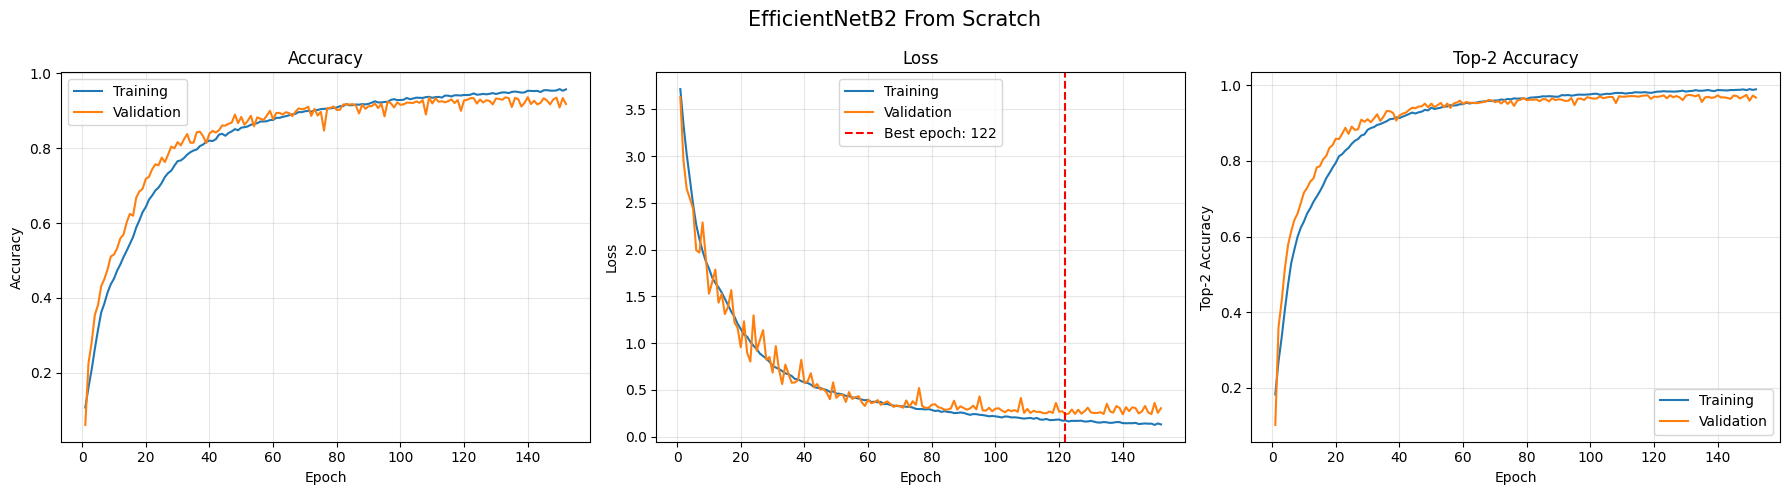

In [8]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# Accuracy
axes[0].plot(
    history_df["epoch"],
    history_df["accuracy"],
    label="Training",
)

axes[0].plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation",
)

axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()


# Loss
axes[1].plot(
    history_df["epoch"],
    history_df["loss"],
    label="Training",
)

axes[1].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation",
)

axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)
axes[1].legend()


# Top-2 accuracy
axes[2].plot(
    history_df["epoch"],
    history_df["top2_accuracy"],
    label="Training",
)

axes[2].plot(
    history_df["epoch"],
    history_df["val_top2_accuracy"],
    label="Validation",
)

axes[2].set_title("Top-2 Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Top-2 Accuracy")
axes[2].grid(alpha=0.3)
axes[2].legend()


plt.suptitle(
    "EfficientNetB2 From Scratch",
    fontsize=15,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "training_curves.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

In [9]:
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    compile=False,
)


test_datagen = ImageDataGenerator()


test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    classes=CLASS_NAMES,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    interpolation="lanczos",
)


test_generator.reset()

y_probability = best_model.predict(
    test_generator,
    verbose=1,
)

y_true = np.asarray(
    test_generator.classes,
    dtype=np.int32,
)
y_predicted = np.argmax(
    y_probability,
    axis=1,
)


test_loss = float(
    np.mean(
        tf.keras.losses.sparse_categorical_crossentropy(
            y_true,
            y_probability,
        ).numpy()
    )
)

test_accuracy = float(
    accuracy_score(
        y_true,
        y_predicted,
    )
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_predicted,
        average="macro",
        zero_division=0,
    )
)

test_top2_accuracy = float(
    top_k_accuracy_score(
        y_true,
        y_probability,
        k=2,
        labels=np.arange(NUM_CLASSES),
    )
)


test_metrics = {
    "loss": test_loss,
    "accuracy": test_accuracy,
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "top2_accuracy": test_top2_accuracy,
}


with open(
    OUTPUT_DIR / "test_metrics.json",
    "w",
) as file:
    json.dump(
        test_metrics,
        file,
        indent=4,
    )


print("Test results")

for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Found 2691 validated image filenames belonging to 35 classes.
85/85 ━━━━━━━━━━━━━━━━━━━━ 32s 276ms/step
Test results
loss: 0.2053
accuracy: 0.9420
macro_precision: 0.7888
macro_recall: 0.7980
macro_f1: 0.7908
top2_accuracy: 0.9773


In [10]:
report = classification_report(
    y_true,
    y_predicted,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)


report_df = pd.DataFrame(
    report
).transpose()

report_df.index.name = "class"

report_df.to_csv(
    OUTPUT_DIR / "classification_report.csv"
)


prediction_df = pd.DataFrame({
    "image_name": [
        Path(filename).name
        for filename in test_generator.filenames
    ],
    "true_class": [
        CLASS_NAMES[index]
        for index in y_true
    ],
    "predicted_class": [
        CLASS_NAMES[index]
        for index in y_predicted
    ],
    "confidence": np.max(
        y_probability,
        axis=1,
    ),
    "correct": y_true == y_predicted,
})


prediction_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)


np.savez_compressed(
    OUTPUT_DIR / "predictions.npz",
    y_true=y_true,
    y_predicted=y_predicted,
    y_probability=y_probability,
    class_names=np.array(CLASS_NAMES),
    image_names=np.array(test_generator.filenames),
)


print("Correct predictions:", int(prediction_df["correct"].sum()))
print("Wrong predictions:", int((~prediction_df["correct"]).sum()))
print("Total predictions:", len(prediction_df))

Correct predictions: 2535
Wrong predictions: 156
Total predictions: 2691


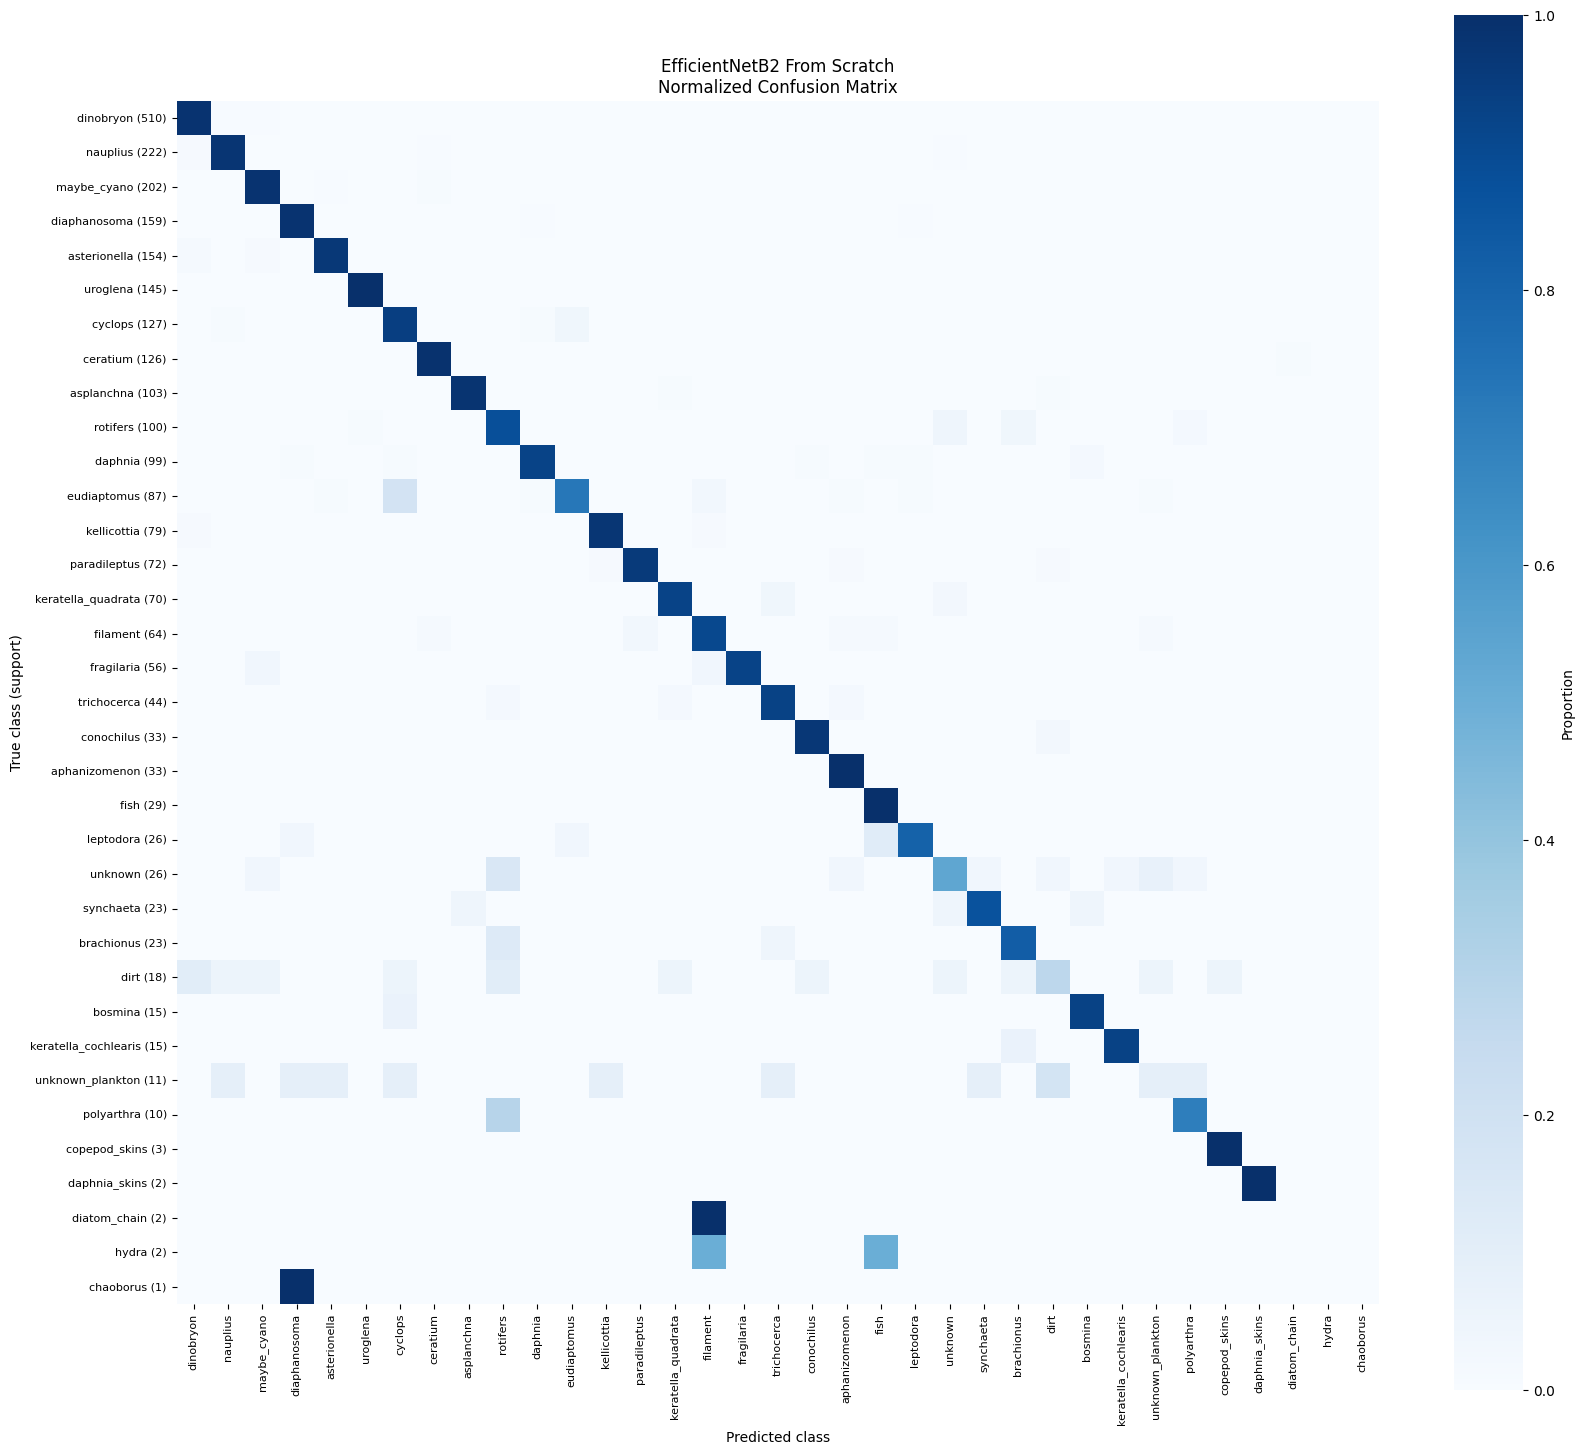

In [11]:
confusion_counts = confusion_matrix(
    y_true,
    y_predicted,
    labels=np.arange(NUM_CLASSES),
)


class_support = confusion_counts.sum(
    axis=1,
    keepdims=True,
)


confusion_normalized = np.divide(
    confusion_counts,
    class_support,
    out=np.zeros_like(
        confusion_counts,
        dtype=float,
    ),
    where=class_support != 0,
)


pd.DataFrame(
    confusion_counts,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
).to_csv(
    OUTPUT_DIR / "confusion_matrix_counts.csv"
)


pd.DataFrame(
    confusion_normalized,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
).to_csv(
    OUTPUT_DIR / "confusion_matrix_normalized.csv"
)


support_values = confusion_counts.sum(axis=1)

class_order = np.argsort(
    -support_values
)


sorted_confusion = confusion_normalized[
    np.ix_(
        class_order,
        class_order,
    )
]


sorted_x_labels = [
    CLASS_NAMES[index]
    for index in class_order
]

sorted_y_labels = [
    f"{CLASS_NAMES[index]} ({support_values[index]})"
    for index in class_order
]


plt.figure(
    figsize=(17, 15)
)

sns.heatmap(
    sorted_confusion,
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    xticklabels=sorted_x_labels,
    yticklabels=sorted_y_labels,
    cbar_kws={
        "label": "Proportion",
    },
)


plt.title(
    "EfficientNetB2 From Scratch\nNormalized Confusion Matrix"
)

plt.xlabel("Predicted class")
plt.ylabel("True class (support)")

plt.xticks(
    rotation=90,
    fontsize=8,
)

plt.yticks(
    rotation=0,
    fontsize=8,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

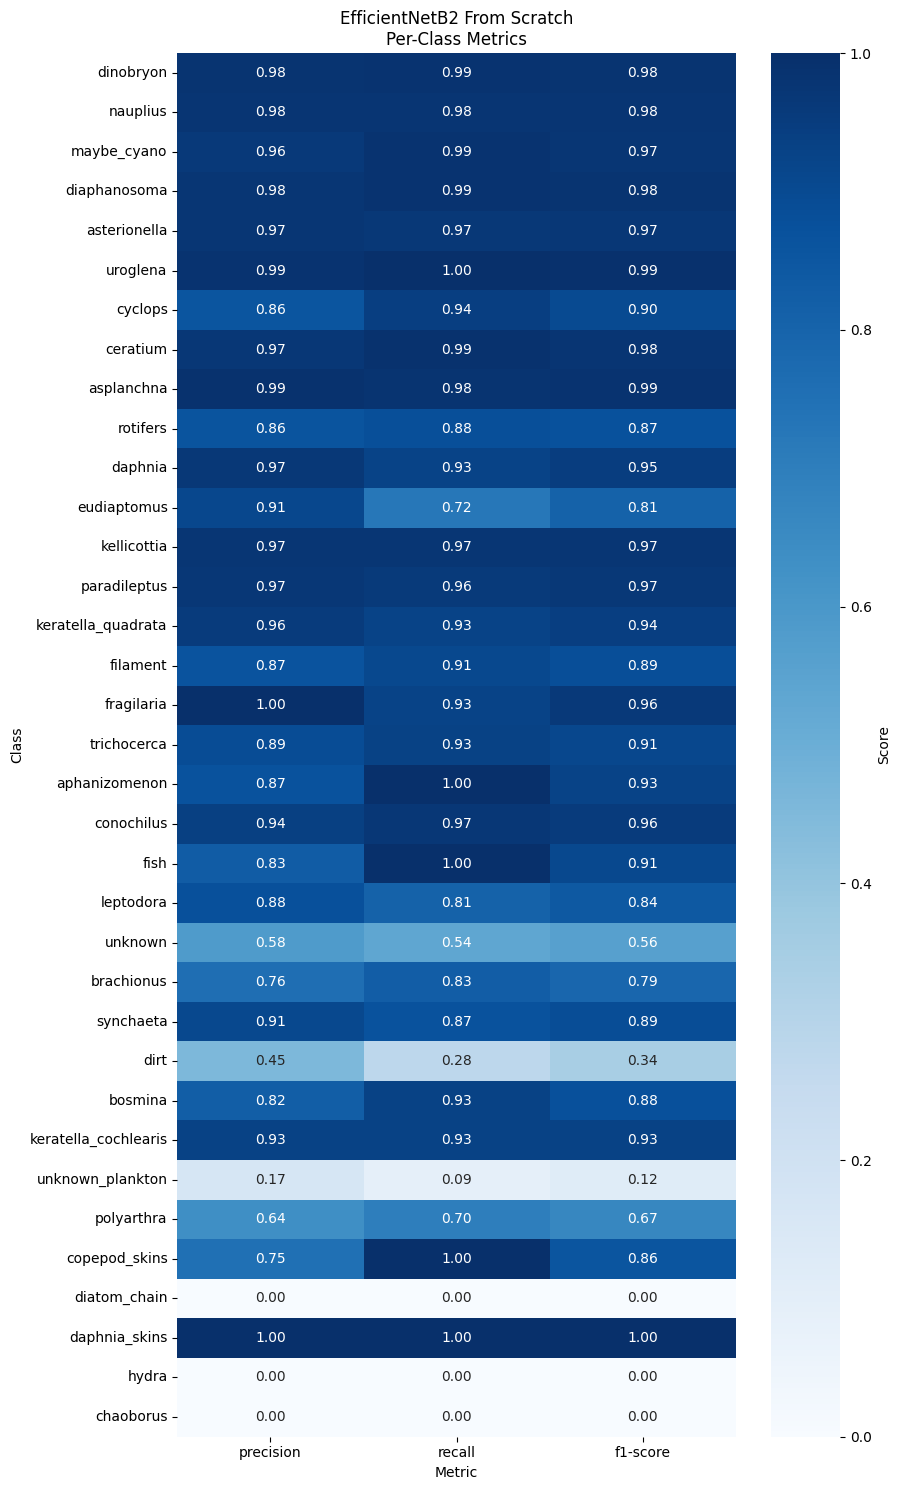

In [12]:
per_class_metrics = report_df.loc[
    CLASS_NAMES,
    [
        "precision",
        "recall",
        "f1-score",
        "support",
    ],
].copy()


per_class_metrics.to_csv(
    OUTPUT_DIR / "per_class_metrics.csv"
)


plot_metrics = per_class_metrics.sort_values(
    by="support",
    ascending=False,
)


plt.figure(
    figsize=(9, 15)
)

sns.heatmap(
    plot_metrics[
        [
            "precision",
            "recall",
            "f1-score",
        ]
    ],
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={
        "label": "Score",
    },
)


plt.title(
    "EfficientNetB2 From Scratch\nPer-Class Metrics"
)

plt.xlabel("Metric")
plt.ylabel("Class")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "per_class_metrics.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

In [13]:
run_config = {
    "run_name": RUN_NAME,
    "model": "EfficientNetB2",
    "initialization": "from_scratch",
    "pretrained_weights": None,
    "seed": SEED,
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "number_of_classes": NUM_CLASSES,
    "training_images": len(train_df),
    "validation_images": len(validation_df),
    "test_images": len(test_df),
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "maximum_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "checkpoint_monitor": "val_loss",
    "reduce_lr_on_plateau": False,
    "preprocessing": (
        "EfficientNet internal preprocessing; "
        "generator pixel range 0-255"
    ),
    "augmentation": {
        "rotation_range": 180,
        "horizontal_flip": True,
        "vertical_flip": True,
        "zoom_range": 0.20,
        "shear_range": 10,
    },
    "completed_epochs": int(len(history_df)),
    "best_epoch": best_epoch,
    "training_seconds": float(training_seconds),
    "total_parameters": int(best_model.count_params()),
}


with open(
    OUTPUT_DIR / "run_config.json",
    "w",
) as file:
    json.dump(
        run_config,
        file,
        indent=4,
    )


pd.DataFrame([
    {
        "run_name": RUN_NAME,
        "best_epoch": best_epoch,
        **test_metrics,
    }
]).to_csv(
    OUTPUT_DIR / "summary_metrics.csv",
    index=False,
)


with open(
    OUTPUT_DIR / "model_summary.txt",
    "w",
) as file:
    best_model.summary(
        print_fn=lambda line: file.write(
            line + "\n"
        )
    )


ZIP_PATH = (
    Path("/kaggle/working")
    / f"{RUN_NAME}_results.zip"
)


with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:

    for file_path in sorted(
        OUTPUT_DIR.rglob("*")
    ):
        if file_path.is_file():
            zip_file.write(
                file_path,
                arcname=file_path.relative_to(
                    OUTPUT_DIR.parent
                ),
            )


print("Results saved in:", OUTPUT_DIR)
print("ZIP created:", ZIP_PATH)

print("\nFiles:")

for file_path in sorted(
    OUTPUT_DIR.iterdir()
):
    print(" -", file_path.name)

Results saved in: /kaggle/working/efficientnetb2_clean_split_from_scratch_seed12345
ZIP created: /kaggle/working/efficientnetb2_clean_split_from_scratch_seed12345_results.zip

Files:
 - best_from_scratch_model.keras
 - classification_report.csv
 - confusion_matrix_counts.csv
 - confusion_matrix_normalized.csv
 - confusion_matrix_normalized.png
 - model_summary.txt
 - per_class_metrics.csv
 - per_class_metrics.png
 - predictions.npz
 - run_config.json
 - summary_metrics.csv
 - test_metrics.json
 - test_predictions.csv
 - training_curves.png
 - training_history.csv
 - training_info.json
